# Histograms for one continuous variable
Bar charts won't work to see the distribution of continous variables across values since there are so many unique values. Instead, we'll plot these using **histograms**. Histograms display how many values are between intervals to quickly get an idea of where the most frequent values are concentrated.

Here's how to do that using Seaborn.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load GapMinder data
gap_url = 'https://raw.githubusercontent.com/chendaniely/pandas_for_everyone/master/data/gapminder.tsv'
gap = pd.read_csv(gap_url, sep='\t')
gap.info()
gap.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1704 entries, 0 to 1703
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   country    1704 non-null   object 
 1   continent  1704 non-null   object 
 2   year       1704 non-null   int64  
 3   lifeExp    1704 non-null   float64
 4   pop        1704 non-null   int64  
 5   gdpPercap  1704 non-null   float64
dtypes: float64(2), int64(2), object(2)
memory usage: 80.0+ KB


,country,continent,year,lifeExp,pop,gdpPercap
0,Afghanistan,Asia,1952,28.801,8425333,779.445314
1,Afghanistan,Asia,1957,30.332,9240934,820.853030
2,Afghanistan,Asia,1962,31.997,10267083,853.100710
3,Afghanistan,Asia,1967,34.020,11537966,836.197138
4,Afghanistan,Asia,1972,36.088,13079460,739.981106


The figure-level function for plotting distributions of continuous variables is `displot()`. Let's use that to create a histogram.

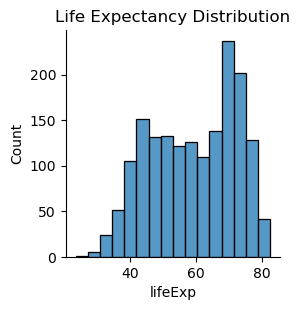

In [4]:
sns.displot(data=gap, x='lifeExp', kind='hist', height=3)
plt.title("Life Expectancy Distribution")
plt.show()


You can set the number of intervals, or "bins", that Seaborn uses to plot the histogram.

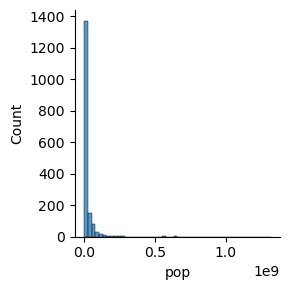

In [13]:
sns.displot(data=gap, x='pop', kind='hist', bins=50, height=3)
plt.show()


A small number of bins is usually preferred to get a general sense of the distribution. Larger datasets with more rows can support a greater number of bins. Here's an example of using too many bins:

You can also use the axes-level function `histplot()` to plot histograms:

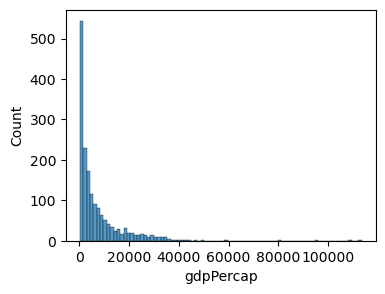

In [11]:
fig, ax = plt.subplots(figsize=(4, 3))

sns.histplot(data=gap, x='gdpPercap')
plt.show()

## KDE plots
An alternative way of viewing the concentration of continuous variable data across values is with a kernel density estimate (KDE). We won't go into how these are calculated, but they provide a smoothed estimate of the distribution viewed as a line graph.

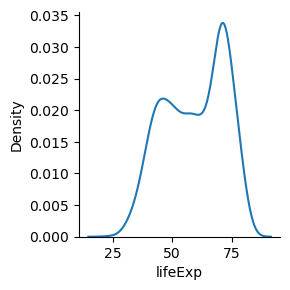

In [14]:
sns.displot(data=gap, x='lifeExp', kind='kde', height=3)
plt.show()

It's possible to examine both histograms and KDE plots together.

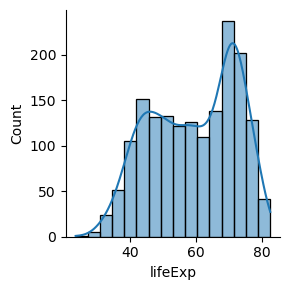

In [15]:
sns.displot(data=gap, x='lifeExp', kind='hist', kde=True, height=3)
plt.show()


It's sometimes useful to select all continuous (numeric) columns to iterate through in a list.

In [16]:
continous_vars = gap.select_dtypes('number').columns
continous_vars

Index(['year', 'lifeExp', 'pop', 'gdpPercap'], dtype='object')

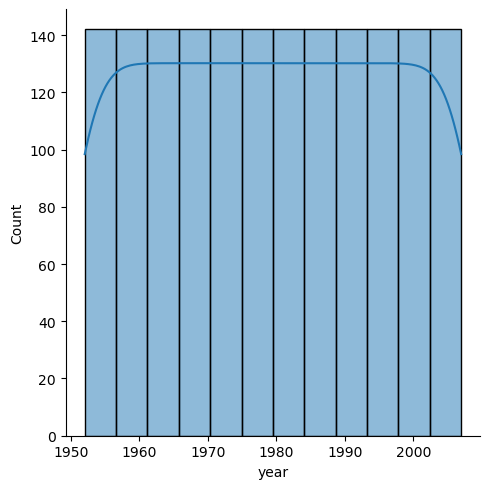

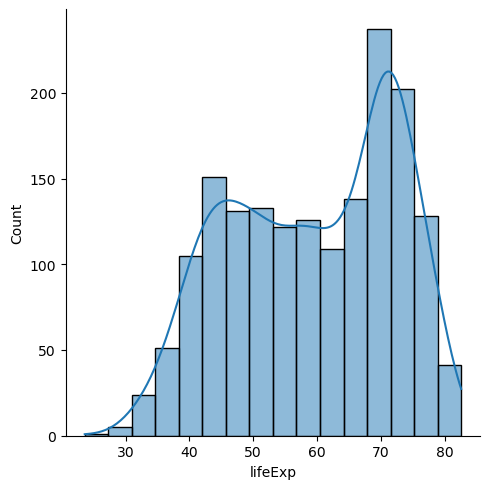

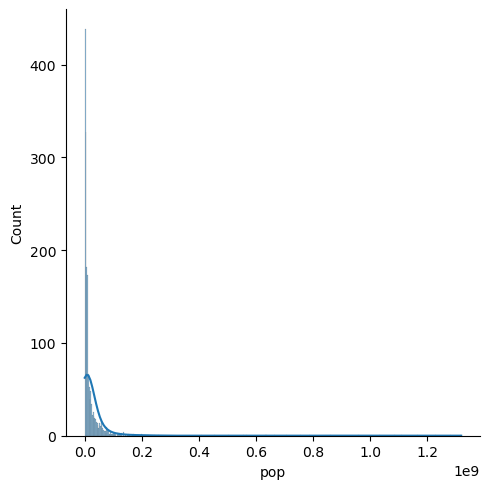

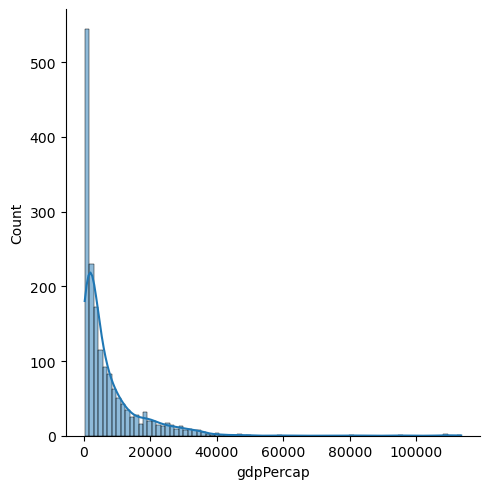

In [18]:
for var in continous_vars:
    sns.displot(data=gap, x=var, kind='hist', kde=True, height=5)